# Final Digit Recognition Pipeline

This notebook demonstrates the end-to-end inference flow for both models, exactly as the API performs it when a user draws on the canvas.

## Learning Objectives
- See how an image propagates to a final prediction.
- Compare the NumPy Dense Network vs the PyTorch CNN.

In [1]:
import sys
import pathlib

# Dynamically resolve project root
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
print(f"Project root added to path: {PROJECT_ROOT}")

Project root added to path: D:\project\DIGIT Recognition


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from backend.app.model.network import NeuralNetwork
from backend.app.model.cnn import SimpleCNN
from backend.app.dataset.mnist_loader import load_mnist

# 1. Load Both Production Models
numpy_model = NeuralNetwork()
numpy_model.load(PROJECT_ROOT / "backend" / "weights" / "model.npz")

cnn_model = SimpleCNN()
cnn_model.load_state_dict(torch.load(PROJECT_ROOT / "backend" / "weights" / "cnn_model.pt", weights_only=True))
cnn_model.eval()

# 2. Get Input Data
images, labels = load_mnist(split="test", subset_size=10, flat=False)
sample = images[4] # Pick a random sample
true_label = labels[4]

# 3. Format inputs for each model
flat_input = sample.reshape(1, 784)
tensor_input = torch.tensor(sample).unsqueeze(0).unsqueeze(0) # (1, 1, 28, 28)

print("Models loaded and data prepared!")

Models loaded and data prepared!


## Inference and Comparison

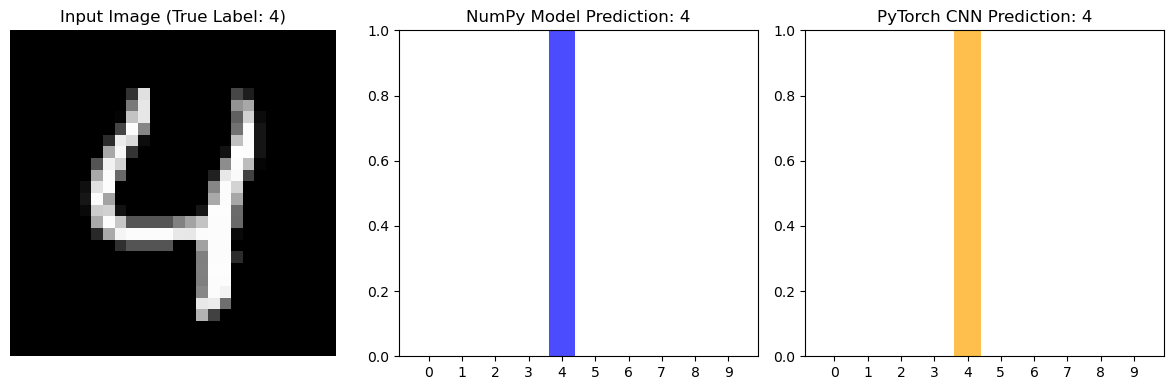

In [3]:
# NumPy Inference
numpy_probs = numpy_model.forward(flat_input, training=False)[0]
numpy_pred = np.argmax(numpy_probs)

# PyTorch CNN Inference
with torch.no_grad():
    logits = cnn_model(tensor_input)
    cnn_probs = torch.nn.functional.softmax(logits, dim=1).numpy()[0]
    cnn_pred = np.argmax(cnn_probs)

# Plotting the comparison
fig = plt.figure(figsize=(12, 4))

# Subplot 1: Image
ax1 = plt.subplot(131)
ax1.imshow(sample, cmap='gray')
ax1.set_title(f"Input Image (True Label: {true_label})")
ax1.axis('off')

# Subplot 2: NumPy Probabilities
classes = np.arange(10)
ax2 = plt.subplot(132)
ax2.bar(classes, numpy_probs, color='blue', alpha=0.7)
ax2.set_xticks(classes)
ax2.set_title(f"NumPy Model Prediction: {numpy_pred}")
ax2.set_ylim(0, 1)

# Subplot 3: CNN Probabilities
ax3 = plt.subplot(133)
ax3.bar(classes, cnn_probs, color='orange', alpha=0.7)
ax3.set_xticks(classes)
ax3.set_title(f"PyTorch CNN Prediction: {cnn_pred}")
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Key Takeaways
- Both models are highly confident and correct on standard MNIST data.
- In production, the CNN handles varied strokes and off-center drawings significantly better due to its spatial invariance.

## Interview Questions
- **What is the tradeoff between model complexity and performance?** A simple Dense network (like the NumPy model) is incredibly fast and conceptually simple but lacks spatial understanding. A CNN requires more memory and specialized libraries (PyTorch) but provides far superior robustness for computer vision tasks.